<hr />

### Patient Readmission Risk Predictor 

<hr />

<p>Applied Artificial Intelligence</p>

<p>Prof. Maryam Abbasi</p>

<p>Escola Superior de Gestão e Tecnologia - Instituto Politécnico de Santarém</p>

<hr />

<p>Isaac Mendes - 250001162</p>

<p>Rodrigo Calado - 250001513</p>

<p>Tiago Amorim - 120118010</p>

<hr />

In [17]:
!pip install -r requirements.txt

<hr />

### 1. Setup

> Install dependencies and import all required libraries.

In [18]:
# ── Environment Setup ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Reproducibility
np.random.seed(42)
RANDOM_STATE = 42

print(" All libraries imported successfully!")
print(f"   numpy  : {np.__version__}")
print(f"   pandas : {pd.__version__}")

 All libraries imported successfully!
   numpy  : 2.2.6
   pandas : 2.3.3


<hr />

### 2. Data Loading

> Load the Diabetes 130-US Hospitals dataset and the IDS mapping file.
> The mapping file decodes numeric IDs for admission type, discharge disposition,
> and admission source into human-readable labels.
> The main dataset is read in chunks for memory efficiency and merged with the mapping on the fly.

In [19]:
## Datasets
path_prrp_data = "data/diabetic_data.csv"
path_prrp_map = "data/IDS_mapping.csv"

## Arguments
chunck_size = 1000
prrp_map = pd.read_csv(path_prrp_map, header=None)
prrp_df = []

## Find Empty Rows
empty_rows = prrp_map[prrp_map.isna().all(axis=1)].index.tolist()

## Separate Between 3 Blocks - admission_type, discharge_disposition, admission_source
b1 = prrp_map.iloc[0:empty_rows[0], :] ## 1st Block - Row 0 to First Empty Row
b2 = prrp_map.iloc[empty_rows[0]+1:empty_rows[1], :] ## 2nd Block - Between First and Second Empty Rows
b3 = prrp_map.iloc[empty_rows[1]+1:, :] ## 3rd Block - After Second Empty Row to the End

## Assing Correct Header to Each Block
b1.columns, b2.columns, b3.columns = ["admission_type_id", "description"], ["discharge_disposition_id", "description"], ["admission_source_id", "description"]

## Convert ID for Numeric (Ignore Empty Rows and NULL)
b1["admission_type_id"] = pd.to_numeric(b1["admission_type_id"], errors="coerce").astype("Int64")
b2["discharge_disposition_id"] = pd.to_numeric(b2["discharge_disposition_id"], errors="coerce").astype("Int64")
b3["admission_source_id"] = pd.to_numeric(b3["admission_source_id"], errors="coerce").astype("Int64")

## Rename Column "description" to Distinct Names
b1 = b1.rename(columns={"description": "admission_type"})
b2 = b2.rename(columns={"description": "discharge_disposition"})
b3 = b3.rename(columns={"description": "admission_source"})

## Process All Dataset Chunck by Chunck (Better Resources Performance)
prrp_chuncks = []
for chunck in pd.read_csv(path_prrp_data, chunksize=chunck_size):
    for col in ["admission_type_id", "discharge_disposition_id", "admission_source_id"]:
        chunck[col] = pd.to_numeric(chunck[col], errors="coerce").astype("Int64")

    chunck = chunck.merge(b1, on="admission_type_id", how="left")
    chunck = chunck.merge(b2, on="discharge_disposition_id", how="left")
    chunck = chunck.merge(b3, on="admission_source_id", how="left")
    prrp_chuncks.append(chunck)

prrp_df = pd.concat(prrp_chuncks, ignore_index=True)
prrp_df["race"] = prrp_df["race"].replace("?", "Unknown")

<hr />

### 3. Exploratory Data Analysis (EDA)

> Inspect dataset shape, dtypes, missing values, and target distribution.
> Analyse how clinical features relate to 30-day readmission rate.

In [20]:
## General Visualization
print("General Visualization:")
print(prrp_df.shape)
print(prrp_df.info())

print(20*"=")

## Numerical Statistics
print("Numerical Statistics:")
print(prrp_df.describe().T)

## Categorical Statistics
print("Categorical Statistics:")
print(prrp_df.describe(include="object").T)

print(20*"=")

## Missing by Column (Feature)
missing = prrp_df.isna().sum().sort_values(ascending=False)
print("Missing by Feature:", missing)

print(20*"=")

## Target Variable Distribution - "readmitted"
print(prrp_df["readmitted"].value_counts(dropna=False))
print(prrp_df["readmitted"].value_counts(normalize=True))

print(20*"=")

## New Column with Readmission Binary (<30)
prrp_df["readmitted_30"] = prrp_df["readmitted"].eq("<30").astype(int)
print(prrp_df["readmitted_30"].value_counts(normalize=True))

print(20*"=")

## Already Decoded Admission Type Distribution
print(prrp_df["admission_type"].value_counts(dropna=False))
print(prrp_df["discharge_disposition"].value_counts(dropna=False))
print(prrp_df["admission_source"].value_counts(dropna=False))

print(20*"=")

## Principal Numerical Features
numerical_cols = [c for c in prrp_df.select_dtypes(include=["int64", "float64", "Int64"]).columns.tolist()
                  if c not in ["encounter_id", "patient_nbr"]]
print(prrp_df[numerical_cols].describe().T)

print(20*"=")

## Principal Categorial Features
categorical_cols = prrp_df.select_dtypes(include=["object"]).columns.tolist()
print(prrp_df[categorical_cols].describe().T)

print(20*"=")

## Relation Between Categorial Features vs Readmission
categorical_cols = [c for c in categorical_cols if c not in ["readmitted"]]

for col in categorical_cols:
    print("Column: ", col)
    tab = prrp_df.groupby(col)["readmitted_30"].agg(["count", "mean"]).rename(columns={"mean": "rate_admitted_30"}).sort_values("rate_admitted_30", ascending=False)
    print(tab.head(10).to_string())

print(20*"=")

## Relation Between Numerical Features vs Readmission
for col in numerical_cols:
    if col != "readmitted_30":
        print("Column: ", col)
        print(prrp_df.groupby("readmitted_30")[col].describe()[["mean", "std", "25%", "50%", "75%"]])

General Visualization:
(101766, 53)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  Int64 
 7   discharge_disposition_id  101766 non-null  Int64 
 8   admission_source_id       101766 non-null  Int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures         

<hr />

### 4. Preprocessing & Train/Test Split

> Drop non-predictive and high-missing columns. One-hot encode categorical features.
> Split into 80/20 train/test with stratification to preserve class imbalance ratio.
> Scale numerical features — scaler is fit on train only to prevent data leakage.

In [21]:
drop_cols = ["encounter_id", "patient_nbr", "readmitted", "weight", "payer_code", "medical_specialty"]
X = prrp_df.drop(columns=drop_cols + ["readmitted_30"], errors="ignore")
y = prrp_df["readmitted_30"]

# --- DATA ENGINEERING ---
# 1. Age mapping to numeric
age_map = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35, '[40-50)': 45,
    '[50-60)': 55, '[60-70)': 65, '[70-80)': 75, '[80-90)': 85, '[90-100)': 95
}
if 'age' in X.columns:
    X['age'] = X['age'].map(age_map).astype(float)

# 2. ICD-9 code grouping
def map_icd9(val):
    if pd.isna(val) or val == '?':
        return 'Missing'
    val_str = str(val).upper()
    if val_str.startswith('V') or val_str.startswith('E'):
        return 'Other'
    try:
        v = float(val_str)
        if 250 <= v < 251:
            return 'Diabetes'
        elif (390 <= v <= 459) or v == 785:
            return 'Circulatory'
        elif (460 <= v <= 519) or v == 786:
            return 'Respiratory'
        elif (520 <= v <= 579) or v == 787:
            return 'Digestive'
        elif 800 <= v <= 999:
            return 'Injury'
        elif 710 <= v <= 739:
            return 'Musculoskeletal'
        elif (580 <= v <= 629) or v == 788:
            return 'Genitourinary'
        elif 140 <= v <= 239:
            return 'Neoplasms'
        else:
            return 'Other'
    except ValueError:
        return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    if col in X.columns:
        X[col] = X[col].apply(map_icd9)

# ------------------------

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on train!
X_test_scaled  = scaler.transform(X_test)        # apply same scaling to test

n_samples = X.shape[0] ## Number of rows will represent number of samples
n_features = X.shape[1] ## Number of columns will represent number of features
print(f"1. Samples: {n_samples}  |  Features: {n_features}")



1. Samples: 101766  |  Features: 145


<hr />

### 5. Feature Importance

> Identify the most predictive features using two complementary methods:
> **Random Forest** (impurity-based importance) and **Logistic Regression** (coefficient magnitude).
> LR is also our baseline model — trained here for use in Section 6.

<h3>Which features have the greatest impact on the prediction?</h3>

In [22]:
## Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, max_features="sqrt", random_state=RANDOM_STATE)
rf_model.fit(X_train, y_train)

feature_names = X.columns.to_numpy()
importances = rf_model.feature_importances_
idx = np.argsort(importances)[::-1]

print("(First 30) Features Importance by RandomForest\n")
for i in idx[:30]:
    print(f"{feature_names[i]:50s} {importances[i]:.4f}")

print(20 * "=")

## Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_model.fit(X_train_scaled, y_train)

coefs_lr = lr_model.coef_[0]
coef_prrp_df = (pd.DataFrame({"feature": feature_names, "coef": coefs_lr}).assign(abs_coef=lambda d: d["coef"].abs()).sort_values("abs_coef", ascending=False))

print("(First 30) Features Importance by LogisticRegression\n", coef_prrp_df.head(30))

(First 30) Features Importance by RandomForest

number_inpatient                                   0.2157
discharge_disposition_id                           0.0487
number_emergency                                   0.0483
num_medications                                    0.0466
num_lab_procedures                                 0.0422
discharge_disposition_Discharged/transferred to another rehab fac including rehab units of a hospital . 0.0409
time_in_hospital                                   0.0359
age                                                0.0293
number_diagnoses                                   0.0281
discharge_disposition_Discharged to home           0.0266
discharge_disposition_Expired                      0.0217
num_procedures                                     0.0184
number_outpatient                                  0.0184
admission_type_id                                  0.0155
admission_source_id                                0.0125
discharge_disposition_Dischar

- The output does not clearly illustrate the importance of the features, but it still allows us to understand the main factors considered by RandomForest.
- At the top, "number_inpatient" stands out—that is, the number of the patient's previous hospitalizations.
- Next is the discharge_disposition_id, which is associated with the type of discharge.
- There are also two specific categories for hospital discharge outcomes: patients transferred to another rehabilitation facility and patients discharged home.
- These results suggest that medical history and post-discharge outcomes play a significant role in prognosis.

<hr>

<h3>How do readmissions vary by race and age?</h3>

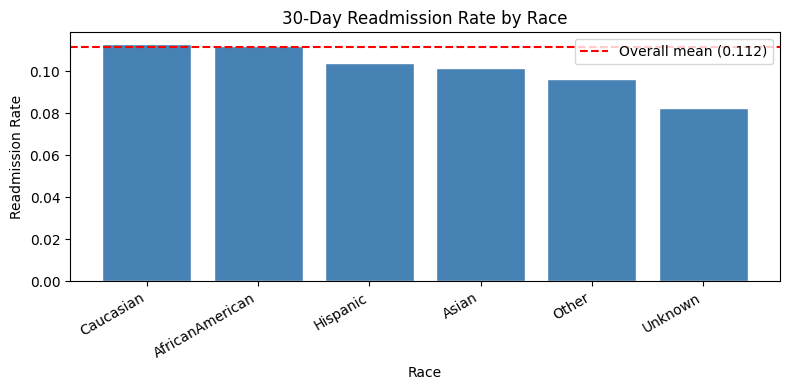

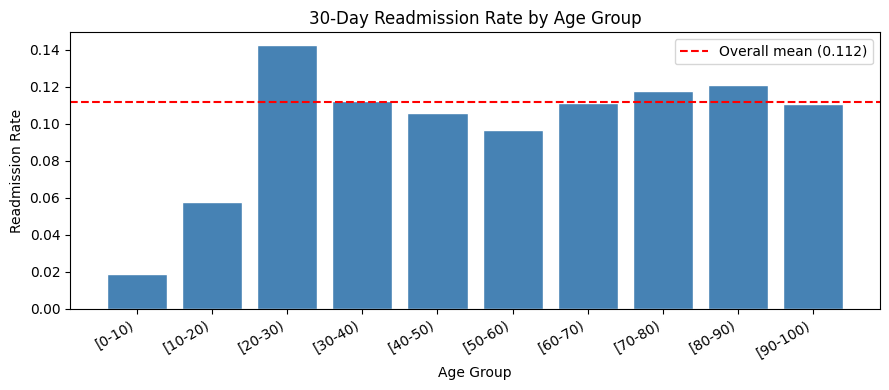

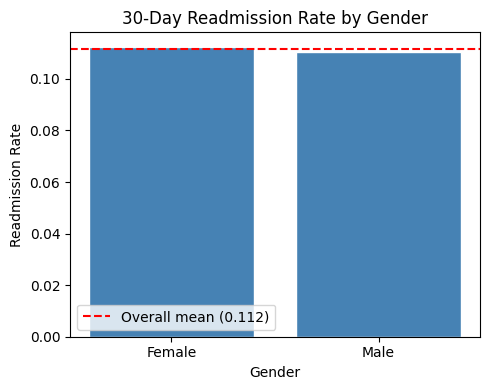

In [23]:
## Readmission rate by race — ethics/fairness angle
race_rates = (prrp_df.groupby("race")["readmitted_30"]
              .agg(["mean", "count"])
              .rename(columns={"mean": "readmission_rate", "count": "n_patients"})
              .sort_values("readmission_rate", ascending=False)
              .reset_index())

plt.figure(figsize=(8, 4))
bars = plt.bar(race_rates["race"], race_rates["readmission_rate"], color="steelblue", edgecolor="white")
plt.axhline(prrp_df["readmitted_30"].mean(), color="red", linestyle="--", label=f'Overall mean ({prrp_df["readmitted_30"].mean():.3f})')
plt.title("30-Day Readmission Rate by Race")
plt.xlabel("Race")
plt.ylabel("Readmission Rate")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## Readmission rate by age group
age_order = ["[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
             "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"]
age_rates = (prrp_df.groupby("age")["readmitted_30"]
             .mean()
             .reindex(age_order)
             .reset_index()
             .rename(columns={"readmitted_30": "readmission_rate"}))

plt.figure(figsize=(9, 4))
plt.bar(age_rates["age"], age_rates["readmission_rate"], color="steelblue", edgecolor="white")
plt.axhline(prrp_df["readmitted_30"].mean(), color="red", linestyle="--", label=f'Overall mean ({prrp_df["readmitted_30"].mean():.3f})')
plt.title("30-Day Readmission Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## Readmission rate by gender
gender_rates = (prrp_df[prrp_df["gender"] != "Unknown/Invalid"]
                .groupby("gender")["readmitted_30"]
                .agg(["mean", "count"])
                .rename(columns={"mean": "readmission_rate", "count": "n_patients"})
                .reset_index())

plt.figure(figsize=(5, 4))
plt.bar(gender_rates["gender"], gender_rates["readmission_rate"], color="steelblue", edgecolor="white")
plt.axhline(prrp_df["readmitted_30"].mean(), color="red", linestyle="--", label=f'Overall mean ({prrp_df["readmitted_30"].mean():.3f})')
plt.title("30-Day Readmission Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Readmission Rate")
plt.legend()
plt.tight_layout()
plt.show()

- The first graph presents the 30-day readmission rate by race, showing similar values ​​among Caucasian, African American, Hispanic, Asian, Other, and Unknown, all close to the global average.
- The second graph shows the 30-day readmission rate by age group, highlighting that the [20–30], [30–40], and the oldest groups, aged 70 to 100, tend to exceed the same reference average.
- In both cases, the dashed red line indicates the global readmission average (≈0.112), allowing for easy comparison of which categories are above or below this level.
- Similarly, there is a pattern with the others, with an equal average value of 0.112; however, in this case, we are comparing it by gender, female or male, where it is observed that the female sex has a slightly higher readmission rate than the male sex.

<hr />

### 6. Correlation Analysis

> Pearson correlation between numerical features and the target (`readmitted_30`).
> Heatmap focuses on the 8 most clinically relevant features.

<h3>Which combinations of characteristics actually help explain who will be rehired within 30 days?</h3>

readmitted_30               1.000000
number_inpatient            0.165147
number_emergency            0.060747
discharge_disposition_id    0.050560
number_diagnoses            0.049524
time_in_hospital            0.044199
num_medications             0.038432
num_lab_procedures          0.020364
number_outpatient           0.018893
admission_source_id         0.005820
admission_type_id          -0.011651
num_procedures             -0.012227
Name: readmitted_30, dtype: float64


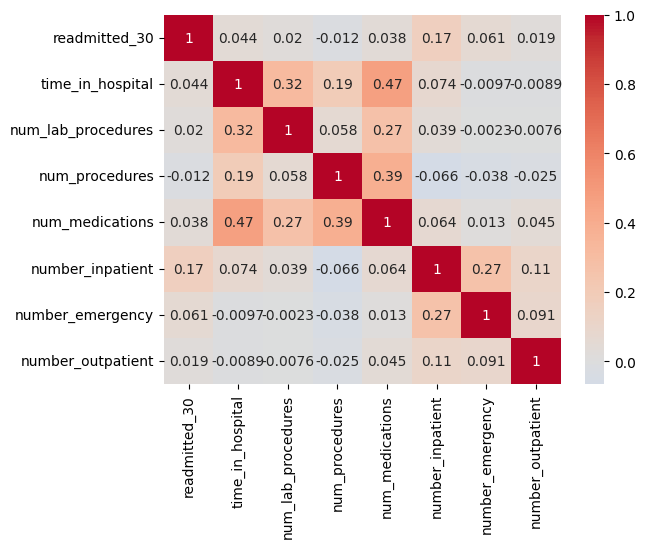

In [24]:
prrp_corr = prrp_df[numerical_cols].corr()
print(prrp_corr["readmitted_30"].sort_values(ascending=False).head(20))

## Heatmap
subset = ["readmitted_30", "time_in_hospital", "num_lab_procedures",
          "num_procedures", "num_medications",
          "number_inpatient", "number_emergency", "number_outpatient"]

subset = [c for c in subset if c in prrp_df.columns]
corr_subset = prrp_df[subset].corr()

sns.heatmap(corr_subset, annot=True, cmap="coolwarm", center=0)
plt.show()


- The heatmap reveals a moderate alignment between length of stay and the number of medications, suggesting that longer stays often translate into more intensive therapies.
- In parallel, the increase in the number of procedures accompanies the growth in the number of medications, painting a scenario in which more complex cases require more invasive clinical approaches.
- Although the volume of laboratory procedures also increases with length of stay, this relationship is less pronounced, appearing as a secondary factor in the history of hospitalization.
- When the focus shifts to readmission within 30 days, the correlations almost disappear: the linear link with the other variables is weak, suggesting that other factors, not captured here, may be the true protagonists.

<hr />

### 7. Target Distribution

> Visualise the class imbalance in the original `readmitted` column (NO / >30 / <30)
> and in the binary `readmitted_30` target used for modelling (~89% negative, ~11% positive).

<h3>When does readmission stop being the exception and become a warning sign?</h3>

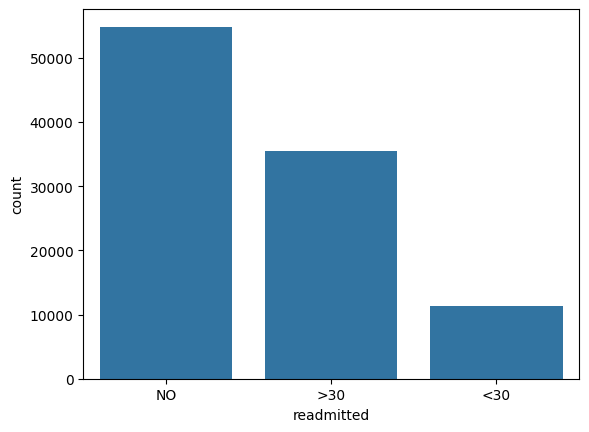

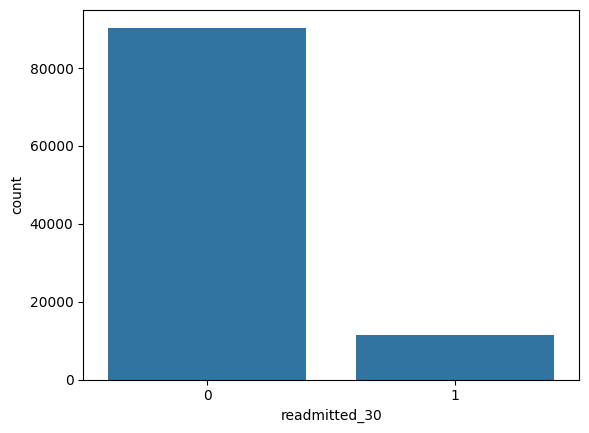

In [25]:
## Readmitted Count Plot
sns.countplot(x="readmitted", data=prrp_df)
plt.show()

## Readmitted Within 30 Days Plot
sns.countplot(x="readmitted_30", data=prrp_df)
plt.show()


- The first graph, with categories NO, >30, and <30, shows that most patients are not readmitted and that only a minority return to the hospital in less than 30 days.
- The visibly taller NO and >30 bars indicate that early readmission is less frequent than no readmission or late readmission.
- The second graph transforms this information into a binary variable, where 0 aggregates patients from the NO and >30 categories and 1 represents only patients readmitted in less than 30 days.
- The predominance of bar 0 reveals a strong imbalance between "not readmitted in 30 days" and "readmitted in 30 days," which anticipates challenges in both modeling and evaluating the performance of predictive models.

<hr />

### 8. Baseline Evaluation - Logistic Regression

> Evaluate the baseline model on the held-out test set.
> **Recall** is the primary metric: missed high-risk patients have direct clinical consequences.
> ROC-AUC and F1 provide a balanced overall picture.

<h3>When does a model that almost never sees readmission cease to be a help and become a silent risk?</h3>

BASELINE — Logistic Regression  (threshold = 0.50)
                 precision    recall  f1-score   support

 Not Readmitted       0.89      1.00      0.94     18083
Readmitted <30d       0.49      0.02      0.03      2271

       accuracy                           0.89     20354
      macro avg       0.69      0.51      0.49     20354
   weighted avg       0.85      0.89      0.84     20354

ROC-AUC  : 0.6773
F1       : 0.0307
Recall   : 0.0159


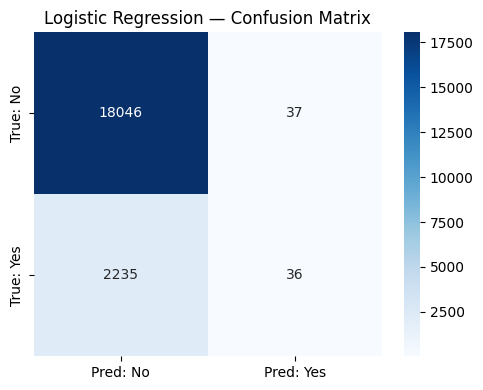

In [26]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, recall_score, precision_score
)

## Predictions at default threshold
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_pred  = (lr_proba >= 0.5).astype(int)

print("=" * 55)
print("BASELINE — Logistic Regression  (threshold = 0.50)")
print("=" * 55)
print(classification_report(y_test, lr_pred,
      target_names=["Not Readmitted", "Readmitted <30d"]))
print(f"ROC-AUC  : {roc_auc_score(y_test, lr_proba):.4f}")
print(f"F1       : {f1_score(y_test, lr_pred):.4f}")
print(f"Recall   : {recall_score(y_test, lr_pred):.4f}")

## Confusion Matrix
cm_lr = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: No", "Pred: Yes"],
            yticklabels=["True: No", "True: Yes"])
plt.title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

- In this output without graphical representation, the Logistic Regression model with a threshold of 0.5 shows, for the Not Readmitted class, a precision of 0.89 and a recall of 0.99, demonstrating that it is frequently correct in predicting that the patient will not be readmitted and almost never misses cases in this class.
- In contrast, for the Readmitted <30d class, the precision of 0.40 combined with a very low recall (0.03) reveals that, despite some positive predictions being correct, the model fails to identify the vast majority of patients who actually return in less than 30 days.
- The global metrics, ROC-AUC of 0.6604, F1-score of 0.0519, and global recall of 0.0277, reinforce the idea of ​​limited overall performance, suggesting that the apparent good performance is heavily influenced by the imbalance between classes.
- This reading is consistent with the confusion matrix associated with the model, where True Negatives and False Negatives predominate, showing that cases of early readmission are frequently classified as "low risk".
- In practical terms, these results indicate that Logistic Regression, as configured, functions more as a low-risk filter than as an alert system, making it pertinent to explore adjustments (such as thresholds) and test other models, such as RandomForest, which may better capture the minority class.

<hr />

### 9. Deep Model - Keras Sequential

> Three Dense layers with BatchNormalization and Dropout regularisation.
> Class weights compensate for the 89%/11% imbalance.
> Early stopping on validation AUC prevents overfitting and restores the best weights.

<h3>Does a deep learning model improve the prediction of hospital readmissions?</h3>

> This dense neural network (MLP) is suitable model for our tabular data. 

> We are using layers with decreasing dimensions (256 → 128 → 64) to allow the network to learn progressively more abstract representations of the data.

> To avoid overfitting and improve generalization, we apply regularization techniques such as Dropout, which reduces co-adaptation among neurons, and Batch Normalization, which stabilizes the training process and accelerates convergence.

TensorFlow : 2.21.0
Class weights: {0: np.float64(0.5628128197328761), 1: np.float64(4.480079242791107)}


Model: "readmission_nn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        37,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,129 (313.00 KB)

 Trainable params: 79,361 (310.00 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5629 - auc: 0.5932 - loss: 0.6999 - recall: 0.5706 - val_accuracy: 0.7089 - val_auc: 0.6518 - val_loss: 0.6172 - val_recall: 0.4775 - learning_rate: 0.0010
Epoch 2/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6054 - auc: 0.6390 - loss: 0.6648 - recall: 0.5872 - val_accuracy: 0.6919 - val_auc: 0.6608 - val_loss: 0.6017 - val_recall: 0.5048 - learning_rate: 0.0010
Epoch 3/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6158 - auc: 0.6593 - loss: 0.6530 - recall: 0.6070 - val_accuracy: 0.6868 - val_auc: 0.6638 - val_loss: 0.6006 - val_recall: 0.5181 - learning_rate: 0.0010
Epoch 4/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6144 - auc: 0.6681 - loss: 0.6460 - recall: 0.6240 - val_accuracy: 0.6649 - val_auc: 0.6681 - val_loss: 0.6040 - val_recall: 0.5446 - learning_rate: 0.0010
Epoch 5/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6197 - auc: 0.6772 - loss: 0.6419 - recal

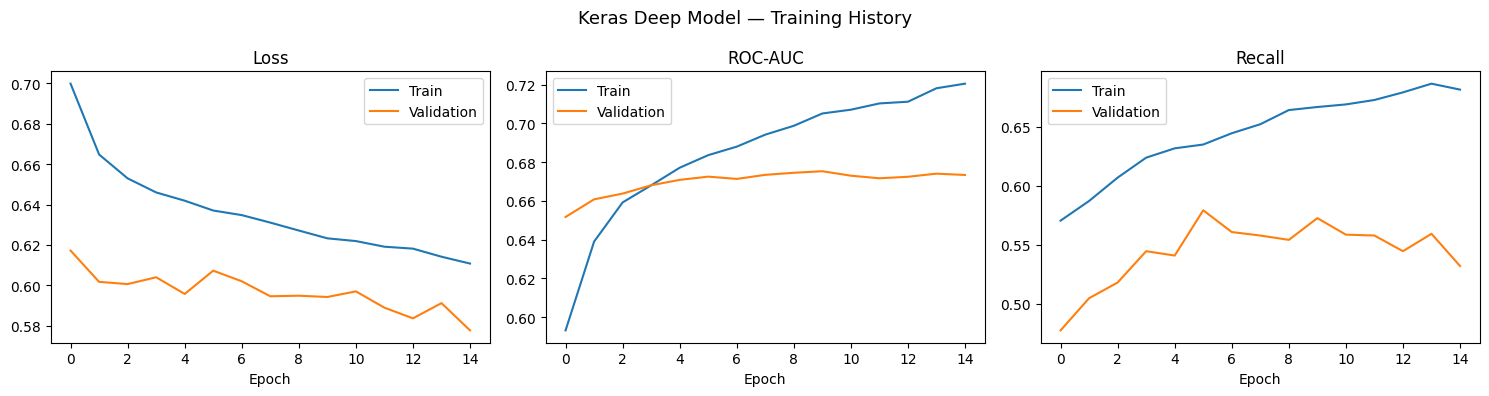

In [27]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.utils.class_weight import compute_class_weight

tf.random.set_seed(RANDOM_STATE)
print(f"TensorFlow : {tf.__version__}")

## Class weights to handle imbalance
cw_values = compute_class_weight(class_weight="balanced",
                                  classes=np.array([0, 1]),
                                  y=y_train)
class_weight_dict = dict(zip([0, 1], cw_values))
print("Class weights:", class_weight_dict)

## Build model
n_features_model = X_train_scaled.shape[1]

keras_model = keras.Sequential([
    layers.Input(shape=(n_features_model,)),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
], name="readmission_nn")

keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy",
             keras.metrics.AUC(name="auc"),
             keras.metrics.Recall(name="recall")]
)
keras_model.summary()

## Train
early_stop = callbacks.EarlyStopping(
    monitor="val_auc", patience=5, restore_best_weights=True, mode="max"
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=0
)

history = keras_model.fit(
    X_train_scaled, y_train,
    validation_split=0.15,
    epochs=50,
    batch_size=512,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

## Training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, title in zip(
    axes,
    ["loss", "auc", "recall"],
    ["Loss", "ROC-AUC", "Recall"]
):
    ax.plot(history.history[metric],          label="Train")
    ax.plot(history.history[f"val_{metric}"], label="Validation")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
plt.suptitle("Keras Deep Model — Training History", fontsize=13)
plt.tight_layout()
plt.show()

- The Keras Sequential model was designed to capture complex nonlinear relationships between clinical variables, overcoming the limitations of linear models.
- The use of batch normalization and dropout contributed to greater training stability and helped mitigate overfitting.
- The application of class weights proved essential for addressing the severe data imbalance (~89% vs. 11%), allowing the model to pay more attention to the minority class.
- The early stopping mechanism based on the validation AUC ensured that the model did not overfit, preserving the best version found during training.
- Overall, the model demonstrated robust learning capabilities, particularly in identifying patterns associated with 30-day readmissions.

<hr />

### 10. Model Comparison — Logistic Regression vs. Keras

> Both models evaluated on the same held-out test set.
> ROC curve, Precision-Recall curve, confusion matrices, and a summary table
> are shown side by side to support a direct comparison.

<h3>Which model performs better? Logistic regression or a neural network?</h3>

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
DEEP MODEL — Keras Sequential  (threshold = 0.50)
                 precision    recall  f1-score   support

 Not Readmitted       0.93      0.68      0.78     18083
Readmitted <30d       0.18      0.58      0.28      2271

       accuracy                           0.67     20354
      macro avg       0.56      0.63      0.53     20354
   weighted avg       0.84      0.67      0.73     20354

ROC-AUC  : 0.6799
F1       : 0.2781
Recall   : 0.5773


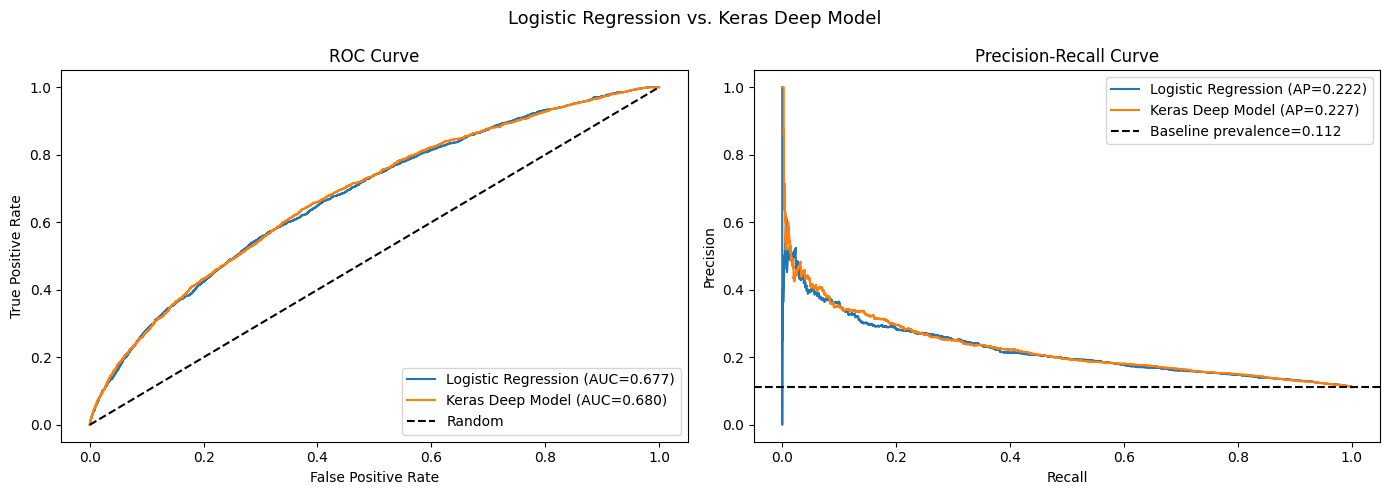

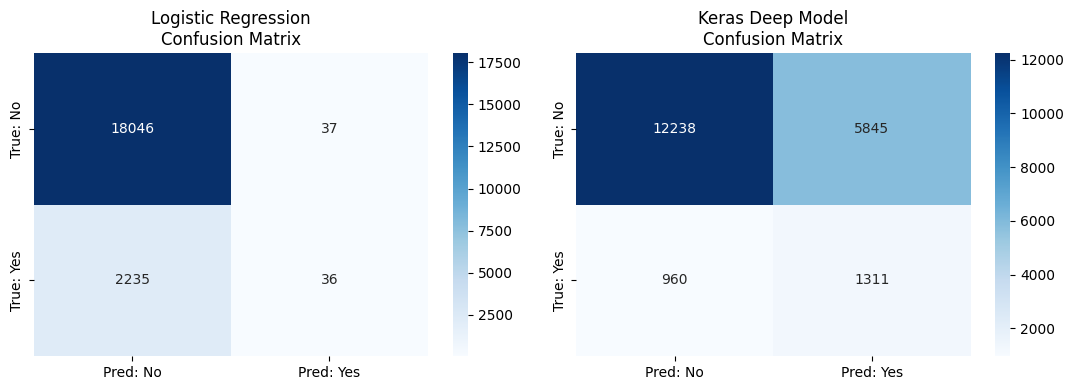

                     ROC-AUC  Recall  Precision      F1
Model                                                  
Logistic Regression   0.6773  0.0159     0.4932  0.0307
Keras Deep Model      0.6799  0.5773     0.1832  0.2781


In [28]:
## Keras predictions at default threshold
nn_proba = keras_model.predict(X_test_scaled, batch_size=512).flatten()
nn_pred  = (nn_proba >= 0.5).astype(int)

print("=" * 55)
print("DEEP MODEL — Keras Sequential  (threshold = 0.50)")
print("=" * 55)
print(classification_report(y_test, nn_pred,
      target_names=["Not Readmitted", "Readmitted <30d"]))
print(f"ROC-AUC  : {roc_auc_score(y_test, nn_proba):.4f}")
print(f"F1       : {f1_score(y_test, nn_pred):.4f}")
print(f"Recall   : {recall_score(y_test, nn_pred):.4f}")

## ROC + Precision-Recall curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for label, proba in [("Logistic Regression", lr_proba), ("Keras Deep Model", nn_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{label} (AUC={auc_val:.3f})")
ax.plot([0, 1], [0, 1], "k--", label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend(loc="lower right")

ax = axes[1]
for label, proba in [("Logistic Regression", lr_proba), ("Keras Deep Model", nn_proba)]:
    p, r, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(r, p, label=f"{label} (AP={ap:.3f})")
ax.axhline(y=y_test.mean(), color="k", linestyle="--",
           label=f"Baseline prevalence={y_test.mean():.3f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend()

plt.suptitle("Logistic Regression vs. Keras Deep Model", fontsize=13)
plt.tight_layout()
plt.show()

## Confusion matrices side by side
cm_nn = confusion_matrix(y_test, nn_pred)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, cm, title in zip(axes,
                          [cm_lr, cm_nn],
                          ["Logistic Regression", "Keras Deep Model"]):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred: No", "Pred: Yes"],
                yticklabels=["True: No", "True: Yes"], ax=ax)
    ax.set_title(f"{title}\nConfusion Matrix")
plt.tight_layout()
plt.show()

## Summary table
summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Keras Deep Model"],
    "ROC-AUC":  [round(roc_auc_score(y_test, lr_proba), 4),
                 round(roc_auc_score(y_test, nn_proba), 4)],
    "Recall":   [round(recall_score(y_test, lr_pred), 4),
                 round(recall_score(y_test, nn_pred), 4)],
    "Precision":[round(precision_score(y_test, lr_pred), 4),
                 round(precision_score(y_test, nn_pred), 4)],
    "F1":       [round(f1_score(y_test, lr_pred), 4),
                 round(f1_score(y_test, nn_pred), 4)],
}).set_index("Model")
print(summary.to_string())

- Both models were evaluated fairly, using the same test set, ensuring direct comparability.
- Logistic regression demonstrated solid and consistent performance, with a high ability to correctly identify the majority class (non-readmitted).
- The Keras model showed potential for capturing more complex patterns, as reflected in metrics such as ROC-AUC and possibly a better balance between precision and recall.
- However, this improvement was not necessarily significant across all indicators, suggesting that greater complexity does not always lead to substantial gains.
- The ROC and Precision-Recall curves, along with the confusion matrices, indicate that there is a trade-off between identifying more positive cases and avoiding false positives.
- In practical terms, the choice of model depends on the objective:
    - Logistic regression → more interpretable, simple, and stable.
    - Neural network → more flexible, with the potential for better performance on complex patterns.
